<a href="https://www.kaggle.com/code/aritrapal3196/patient-experience-nlp-analysis?scriptVersionId=353609585" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Patient Experience & Drug Review NLP Analysis

Star ratings tell you whether patients liked a drug. They don't tell you why. Two drugs can both sit at 7/10 while one of them quietly gives people headaches or makes them gain weight.

In this notebook I go through 160K+ patient reviews and try to answer four things:

1. Does the sentiment of the review text match the rating the patient gave?
2. Which side effects do patients talk about the most?
3. Which side effects go along with bad ratings, and which ones make people stop or switch the drug?
4. Are there drugs that look fine on ratings but have a side effect people keep complaining about?

In [1]:
# imports
import pandas as pd
import numpy as np
import html
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# download vader lexicon
nltk.download('vader_lexicon', quiet=True)

True

## 1. Loading the data
The dataset comes as a train file and a test file. I'm not training a model here, so I just put both together.

In [2]:
train = pd.read_csv('/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv')
test = pd.read_csv('/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTest_raw.csv')

df = pd.concat([train, test], ignore_index=True)
print('Total reviews:', len(df))
df.head()

Total reviews: 215063


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


## 2. Cleaning up the data
There are a few problems in this dataset that I need to deal with first:
- some reviews have no condition written
- some rows have website junk like `3</span> users found this comment helpful.` in the condition column
- the same review sometimes shows up twice, once under the brand name and once under the generic name

In [3]:
# drop rows with missing review/condition
start = len(df)

df = df.dropna(subset=['review', 'condition'])
print('Removed for missing values:', start - len(df))

# remove junk condition rows
junk = df['condition'].str.contains('</span>')
print('Removed junk condition rows:', junk.sum())
df = df[~junk]

# flag brand/generic duplicates
df['is_duplicate'] = df.duplicated(subset=['review', 'condition', 'date', 'rating'])
print('Duplicate reviews found:', df['is_duplicate'].sum())

print('Reviews left:', len(df))

Removed for missing values: 1194
Removed junk condition rows: 1171
Duplicate reviews found: 84761
Reviews left: 212698


## 3. Cleaning the review text
The reviews have HTML codes in them, like `&#039;` instead of an apostrophe. I only fix those and leave everything else alone.

My first version of this notebook removed all punctuation and made everything lowercase. That turned out to be a mistake. VADER uses things like `didn't`, CAPS and `!!!` to work out how positive or negative a sentence is, so removing them changes the score. The small test below shows the difference.

In [4]:
# decode html entities and strip quotes
df['clean_review'] = df['review'].apply(html.unescape).str.strip('"')

# compare raw text vs old cleaning
sia = SentimentIntensityAnalyzer()

sentence = "This didn't help at all. WORST experience ever!!!"
old_way = "this didn t help at all worst experience ever"

print('Kept as it is :', sia.polarity_scores(sentence)['compound'])
print('Old cleaning  :', sia.polarity_scores(old_way)['compound'])

Kept as it is : -0.8388
Old cleaning  : -0.34


## 4. Sentiment scoring
VADER gives every review a score from -1 (very negative) to +1 (very positive).

There's a catch with medical reviews though. VADER thinks words like *pain*, *depression* and *anxiety* are negative. So if someone writes "this finally fixed my depression", the review loses points just for naming the illness.

To get around that I make a second copy of VADER and delete those illness words from its word list. I keep both scores so I can compare them.

In [5]:
# illness words vader treats as negative
illness_words = ['pain', 'depression', 'depressed', 'anxiety', 'anxious', 'cancer',
                 'infection', 'disease', 'disorder', 'panic', 'stress', 'ill',
                 'sick', 'hurt', 'hurts', 'ache', 'aches', 'fear', 'worry', 'worried']

# second analyzer without illness words
sia_adjusted = SentimentIntensityAnalyzer()
for word in illness_words:
    if word in sia_adjusted.lexicon:
        del sia_adjusted.lexicon[word]

# score reviews (slow)
df['sentiment'] = df['clean_review'].apply(lambda text: sia.polarity_scores(text)['compound'])
df['sentiment_adjusted'] = df['clean_review'].apply(lambda text: sia_adjusted.polarity_scores(text)['compound'])

df[['clean_review', 'rating', 'sentiment', 'sentiment_adjusted']].head()

,clean_review,rating,sentiment,sentiment_adjusted
0,"It has no side effect, I take it in combinatio...",9,-0.2960,-0.2960
1,My son is halfway through his fourth week of I...,8,0.9174,0.9174
2,"I used to take another oral contraceptive, whi...",5,0.6160,0.6160
3,This is my first time using any form of birth ...,8,0.7184,0.7184
4,Suboxone has completely turned my life around....,9,0.9403,0.9403


In [6]:
# standard vader thresholds
def label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_adjusted'].apply(label)

# dataset without duplicates
unique = df[df['is_duplicate'] == False]

print(unique['sentiment_label'].value_counts(normalize=True) * 100)

sentiment_label
Positive    53.677200
Negative    41.674418
Neutral      4.648382
Name: proportion, dtype: float64


## 5. Does the text agree with the rating?
If the sentiment scores make sense, reviews with high ratings should read positive and low ratings should read negative. I check this two ways:
- Spearman correlation between rating and sentiment. Ratings go in steps from 1 to 10, so Spearman fits better than normal correlation.
- How often VADER gets the direction right for clearly good ratings (7 to 10) and clearly bad ones (1 to 4).

In [7]:
corr_normal, p1 = spearmanr(unique['rating'], unique['sentiment'])
corr_adjusted, p2 = spearmanr(unique['rating'], unique['sentiment_adjusted'])

print('Spearman correlation (normal VADER)  :', round(corr_normal, 3))
print('Spearman correlation (adjusted VADER):', round(corr_adjusted, 3))

# agreement on clearly good/bad ratings
clear = unique[(unique['rating'] >= 7) | (unique['rating'] <= 4)]

rating_says_good = clear['rating'] >= 7
text_says_good = clear['sentiment_adjusted'] >= 0

agreement = (rating_says_good == text_says_good).mean() * 100
print('Agreement rate:', round(agreement, 1), '%')

Spearman correlation (normal VADER)  : 0.328
Spearman correlation (adjusted VADER): 0.351
Agreement rate: 68.4 %


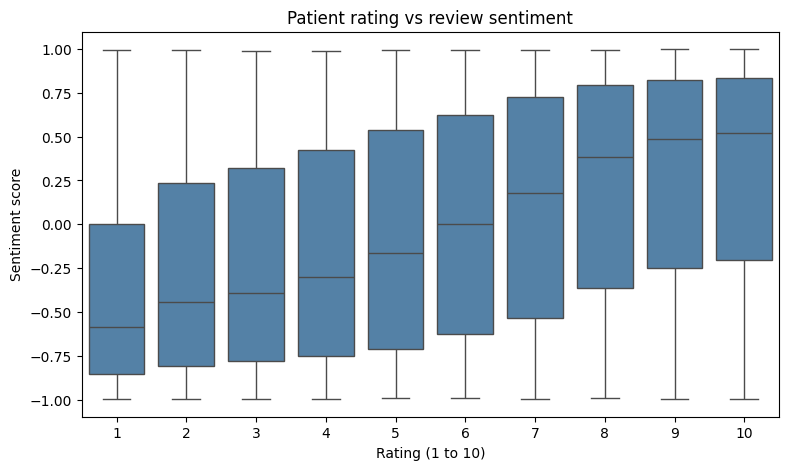

In [8]:
# sentiment by rating
plt.figure(figsize=(9, 5))
sns.boxplot(data=unique, x='rating', y='sentiment_adjusted', color='steelblue', showfliers=False)
plt.title('Patient rating vs review sentiment')
plt.xlabel('Rating (1 to 10)')
plt.ylabel('Sentiment score')
plt.show()

## 6. Finding side effects in the reviews
For each side effect I made a small list of words patients use for it. If a review contains one of those words, I count it as a mention.

Two things I had to be careful about:
- "No nausea" isn't a side effect. If the review says "no nausea", "didn't have any headaches" or "never had dizziness", I don't count it.
- Sometimes the word is the illness itself. Someone reviewing an anxiety medicine will write "anxiety" because that's what they're treating. For those reviews I skip that side effect.

In [9]:
# side effect keywords
side_effects = {
    'Nausea':          ['nausea', 'nauseous', 'vomit', 'throwing up', 'threw up'],
    'Headache':        ['headache', 'migraine'],
    'Weight gain':     ['weight gain', 'gained weight', 'put on weight'],
    'Tiredness':       ['tired', 'fatigue', 'drowsy', 'sleepy', 'exhausted'],
    'Insomnia':        ['insomnia', "can't sleep", 'trouble sleeping'],
    'Dizziness':       ['dizzy', 'dizziness', 'lightheaded'],
    'Anxiety':         ['anxiety', 'anxious', 'panic attack', 'jittery'],
    'Mood swings':     ['mood swing', 'irritable', 'crying', 'emotional'],
    'Stomach issues':  ['diarrhea', 'constipation', 'bloating', 'stomach pain', 'upset stomach'],
    'Skin problems':   ['rash', 'itching', 'itchy', 'hives', 'acne'],
    'Hair loss':       ['hair loss', 'losing my hair', 'hair falling'],
    'Low sex drive':   ['libido', 'sex drive'],
    'Dry mouth':       ['dry mouth'],
    'Spotting':        ['spotting', 'bleeding'],
    'Heart racing':    ['palpitations', 'heart racing', 'racing heart'],
}

# skip side effect when it's the condition itself
skip_for_condition = {
    'Nausea': 'nausea', 'Headache': 'headache|migraine', 'Weight gain': 'weight|obesity',
    'Insomnia': 'insomnia', 'Anxiety': 'anxiety|panic', 'Mood swings': 'depression|bipolar',
    'Skin problems': 'acne|rosacea|psoria|eczema', 'Hair loss': 'alopecia',
    'Low sex drive': 'libido|erectile', 'Spotting': 'bleeding', 'Dizziness': 'vertigo',
}

text = df['clean_review'].str.lower()

for effect, words in side_effects.items():
    mentioned = text.str.contains('|'.join(words))

    # ignore negated mentions
    no_words = []
    for w in words:
        no_words.append('no ' + w)
        no_words.append("didn't have any " + w)
        no_words.append('never had ' + w)
    said_no = text.str.contains('|'.join(no_words))
    df[effect] = (mentioned & ~said_no).astype(float)

    # not applicable for matching conditions
    if effect in skip_for_condition:
        is_the_illness = df['condition'].str.lower().str.contains(skip_for_condition[effect])
        df.loc[is_the_illness, effect] = np.nan

effect_names = list(side_effects.keys())

# any side effect flag
df['any_side_effect'] = (df[effect_names].sum(axis=1) > 0).astype(int)

unique = df[df['is_duplicate'] == False]
print('Reviews that mention at least one side effect:', round(unique['any_side_effect'].mean() * 100, 1), '%')

Reviews that mention at least one side effect: 46.8 %


Nausea            9.5
Tiredness         9.0
Skin problems     8.1
Headache          8.0
Anxiety           7.8
Mood swings       6.8
Stomach issues    5.7
Spotting          5.5
Weight gain       4.3
Dizziness         3.9
Low sex drive     3.2
Insomnia          2.6
Dry mouth         1.9
Heart racing      0.6
Hair loss         0.6
dtype: float64


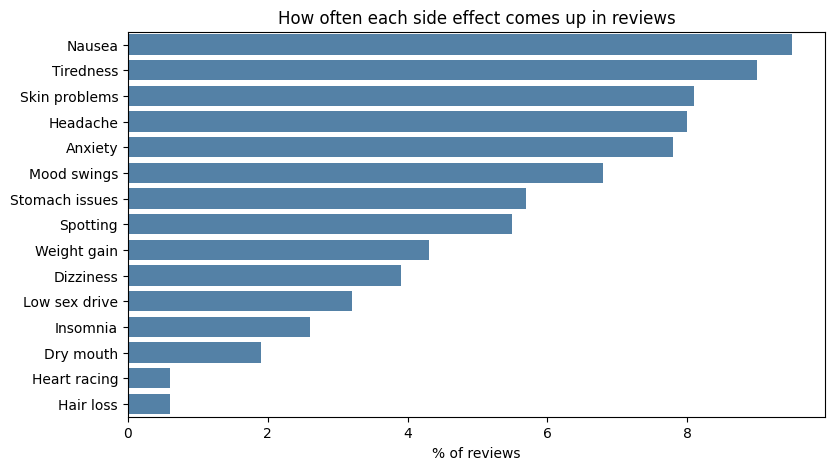

In [10]:
# mention rate per side effect
mention_rate = (unique[effect_names].mean() * 100).sort_values(ascending=False).round(1)
print(mention_rate)

plt.figure(figsize=(9, 5))
sns.barplot(x=mention_rate.values, y=mention_rate.index, color='steelblue')
plt.title('How often each side effect comes up in reviews')
plt.xlabel('% of reviews')
plt.ylabel('')
plt.show()

## 7. Which side effects go with bad ratings?
For each side effect I compare two groups of reviews: the ones that mention it and the ones that don't. Then I look at how many in each group gave a bad rating (1 to 3).

Dividing one percentage by the other gives the relative risk. A relative risk of 2 means reviews that mention that side effect are twice as likely to give a bad rating.

In [11]:
results = []

for effect in effect_names:
    reviews = unique[unique[effect].notna()]

    mentioned = reviews[reviews[effect] == 1]
    not_mentioned = reviews[reviews[effect] == 0]

    # skip rare ones
    if len(mentioned) < 50:
        continue

    bad_with = (mentioned['rating'] <= 3).mean() * 100
    bad_without = (not_mentioned['rating'] <= 3).mean() * 100

    results.append({
        'Side effect': effect,
        'Reviews mentioning it': len(mentioned),
        'Avg rating (mentioned)': round(mentioned['rating'].mean(), 2),
        'Avg rating (not mentioned)': round(not_mentioned['rating'].mean(), 2),
        'Bad rating % (mentioned)': round(bad_with, 1),
        'Bad rating % (not mentioned)': round(bad_without, 1),
        'Relative risk': round(bad_with / bad_without, 2),
    })

bad_rating_table = pd.DataFrame(results).sort_values('Relative risk', ascending=False)
bad_rating_table

,Side effect,Reviews mentioning it,Avg rating (mentioned),Avg rating (not mentioned),Bad rating % (mentioned),Bad rating % (not mentioned),Relative risk
14,Heart racing,777,5.46,7.01,39.1,21.6,1.81
9,Skin problems,9905,5.70,7.10,33.8,20.8,1.62
7,Mood swings,7948,5.76,7.08,33.5,21.1,1.59
10,Hair loss,729,5.58,7.01,34.2,21.6,1.58
5,Dizziness,4997,5.82,7.05,32.0,21.3,1.50
1,Headache,10035,5.96,7.07,31.2,21.0,1.48
0,Nausea,12049,6.07,7.10,29.5,20.9,1.41
13,Spotting,6916,6.22,7.08,27.8,21.0,1.33
8,Stomach issues,7296,6.25,7.05,27.8,21.3,1.31
6,Anxiety,9268,6.45,6.98,27.5,21.9,1.26


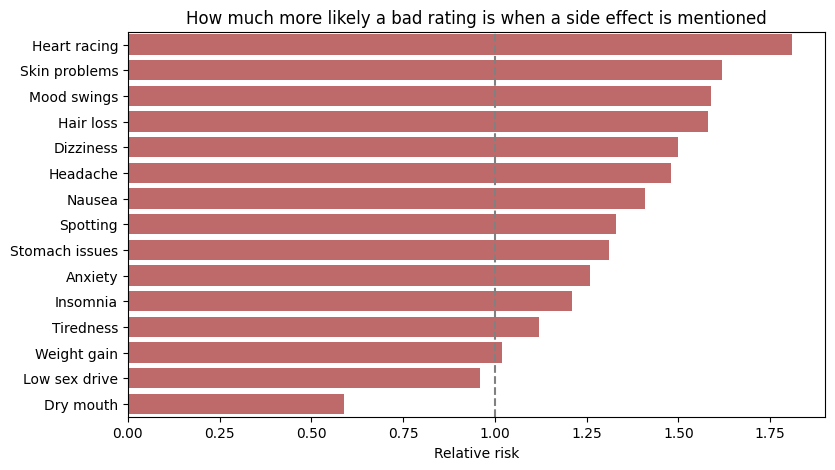

In [12]:
plt.figure(figsize=(9, 5))
sns.barplot(data=bad_rating_table, x='Relative risk', y='Side effect', color='indianred')
plt.axvline(1, color='grey', linestyle='--')
plt.title('How much more likely a bad rating is when a side effect is mentioned')
plt.ylabel('')
plt.show()

## 8. Comparing drugs for the same condition
Comparing a depression drug with an acne cream isn't really fair since people describe them so differently. So here I only compare drugs for the same condition. I take the 6 conditions with the most reviews and only keep drugs with at least 200 reviews, so the percentages aren't based on a handful of people.

In [13]:
# top 6 conditions
top_conditions = unique['condition'].value_counts().head(6).index
print('Conditions I look at:', list(top_conditions))

# keep duplicates for drug-level view
top = df[df['condition'].isin(top_conditions)]

drug_table = top.groupby(['condition', 'drugName']).agg(
    reviews=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    avg_sentiment=('sentiment_adjusted', 'mean'),
    side_effect_pct=('any_side_effect', 'mean'),
).reset_index()

# side effect % per drug
effect_pct = top.groupby(['condition', 'drugName'])[effect_names].mean().reset_index()
drug_table = drug_table.merge(effect_pct, on=['condition', 'drugName'])

# min 200 reviews, convert to %
drug_table = drug_table[drug_table['reviews'] >= 200]
drug_table['side_effect_pct'] = drug_table['side_effect_pct'] * 100
drug_table[effect_names] = drug_table[effect_names] * 100

drug_table.round(1).head(10)

Conditions I look at: ['Birth Control', 'Depression', 'Pain', 'Anxiety', 'Acne', 'Insomnia']


,condition,drugName,reviews,avg_rating,avg_sentiment,side_effect_pct,Nausea,Headache,Weight gain,Tiredness,...,Dizziness,Anxiety,Mood swings,Stomach issues,Skin problems,Hair loss,Low sex drive,Dry mouth,Spotting,Heart racing
2,Acne,Accutane,431,8.4,0.3,15.1,0.2,3.2,0.0,2.6,...,0.0,2.6,5.3,0.7,NaN,1.2,0.2,0.2,0.7,0.0
6,Acne,Adapalene,238,7.2,0.2,1.7,0.0,0.4,0.0,0.8,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.4,0.0
7,Acne,Adapalene / benzoyl peroxide,547,7.4,0.3,2.0,0.0,0.0,0.2,0.2,...,0.0,0.0,1.5,0.0,NaN,0.0,0.0,0.0,0.2,0.0
25,Acne,Benzoyl peroxide / clindamycin,356,8.0,0.4,0.8,0.0,0.0,0.0,0.3,...,0.0,0.3,0.3,0.0,NaN,0.0,0.0,0.0,0.0,0.0
43,Acne,Doxycycline,500,7.3,0.2,21.8,14.8,2.8,0.4,1.6,...,0.6,0.8,0.6,3.6,NaN,0.4,0.2,0.0,0.2,0.0
44,Acne,Drospirenone / ethinyl estradiol,267,7.0,0.1,46.1,8.6,9.0,5.6,8.6,...,1.5,5.2,16.9,1.9,NaN,0.7,8.2,0.4,6.7,0.0
48,Acne,Epiduo,483,7.4,0.3,2.3,0.0,0.0,0.2,0.2,...,0.0,0.0,1.7,0.0,NaN,0.0,0.0,0.0,0.2,0.0
54,Acne,Ethinyl estradiol / norgestimate,270,5.9,0.0,46.3,15.6,8.9,7.4,4.1,...,1.1,7.0,17.0,3.3,NaN,1.1,5.2,0.0,5.6,0.4
63,Acne,Isotretinoin,682,8.4,0.3,15.8,0.6,3.2,0.0,4.3,...,0.0,2.5,4.4,0.7,NaN,0.9,0.1,0.1,0.9,0.1
75,Acne,Minocycline,333,6.3,0.0,30.3,10.2,8.4,0.3,4.8,...,10.8,3.0,1.2,3.6,NaN,0.6,0.0,0.3,0.0,0.0


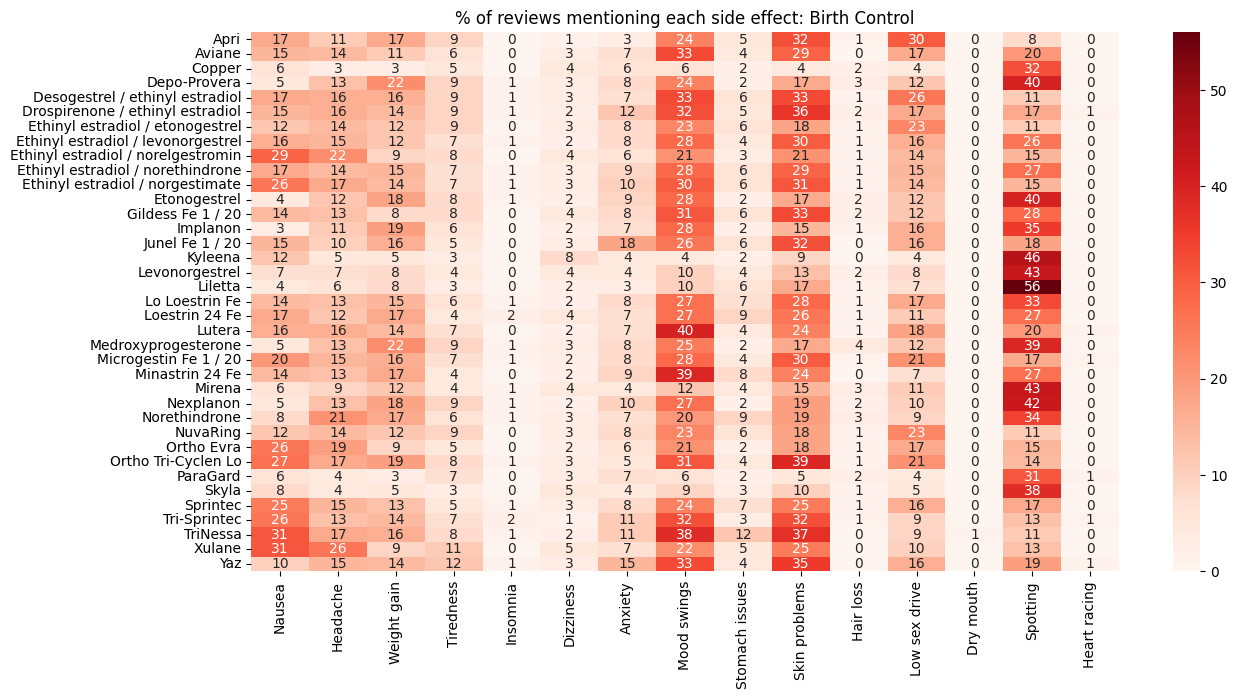

In [14]:
# heatmap for biggest condition
biggest = top_conditions[0]
heat = drug_table[drug_table['condition'] == biggest].set_index('drugName')[effect_names]
heat = heat.dropna(axis=1, how='all')

plt.figure(figsize=(14, 7))
sns.heatmap(heat.round(0), annot=True, fmt='.0f', cmap='Reds')
plt.title('% of reviews mentioning each side effect: ' + biggest)
plt.ylabel('')
plt.show()

## 9. Hidden side effects
This is the main thing I wanted to find. I'm calling it a hidden side effect when:
- its rating looks fine (at or above the middle rating for its condition), but
- one side effect shows up in its reviews at least 1.5 times more than it does for other drugs treating the same condition, and in at least 5% of its reviews.

These are the problems you'd miss if you only looked at star ratings.

In [15]:
hidden = []

for condition in top_conditions:
    drugs = drug_table[drug_table['condition'] == condition]
    if len(drugs) == 0:
        continue

    middle_rating = drugs['avg_rating'].median()

    # condition-level side effect rates
    condition_reviews = top[top['condition'] == condition]
    condition_avg = condition_reviews[effect_names].mean() * 100

    # drugs rated at/above median
    good_drugs = drugs[drugs['avg_rating'] >= middle_rating]

    for i, drug in good_drugs.iterrows():
        for effect in effect_names:
            drug_pct = drug[effect]
            avg_pct = condition_avg[effect]

            if pd.isna(drug_pct) or pd.isna(avg_pct) or avg_pct == 0:
                continue

            if drug_pct >= 5 and drug_pct / avg_pct >= 1.5:
                hidden.append({
                    'Condition': condition,
                    'Drug': drug['drugName'],
                    'Avg rating': round(drug['avg_rating'], 2),
                    'Side effect': effect,
                    'Drug %': round(drug_pct, 1),
                    'Condition avg %': round(avg_pct, 1),
                    'Times higher': round(drug_pct / avg_pct, 2),
                })

hidden_table = pd.DataFrame(hidden)
print('Hidden side effects found:', len(hidden_table))
if len(hidden_table) > 0:
    hidden_table = hidden_table.sort_values('Times higher', ascending=False)
hidden_table.head(15)

Hidden side effects found: 35


,Condition,Drug,Avg rating,Side effect,Drug %,Condition avg %,Times higher
32,Acne,Spironolactone,7.81,Dizziness,8.8,1.2,7.29
30,Acne,Spironolactone,7.81,Weight gain,8.8,1.6,5.47
33,Insomnia,Quetiapine,7.95,Weight gain,9.9,2.3,4.32
3,Birth Control,Kyleena,7.62,Dizziness,7.8,2.8,2.80
19,Birth Control,TriNessa,6.20,Stomach issues,12.1,4.3,2.78
25,Depression,Mirtazapine,7.34,Weight gain,15.4,5.7,2.69
31,Acne,Spironolactone,7.81,Tiredness,7.1,2.7,2.68
17,Birth Control,TriNessa,6.20,Nausea,30.7,12.4,2.48
1,Birth Control,Ethinyl estradiol / norelgestromin,6.80,Nausea,28.5,12.4,2.30
26,Depression,Mirtazapine,7.34,Insomnia,16.8,7.5,2.23


## 10. Does removing illness words change which conditions look worst?
Here I rank conditions by sentiment twice, once with normal VADER and once with the adjusted one. If a condition jumps up a lot after the fix, normal VADER was making it look worse than it really is just because of the words people use.

In [16]:
condition_table = unique.groupby('condition').agg(
    reviews=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    sentiment_normal=('sentiment', 'mean'),
    sentiment_adjusted=('sentiment_adjusted', 'mean'),
).reset_index()

# min 100 reviews
condition_table = condition_table[condition_table['reviews'] >= 100]

# rank shift after adjustment
condition_table['rank_normal'] = condition_table['sentiment_normal'].rank()
condition_table['rank_adjusted'] = condition_table['sentiment_adjusted'].rank()
condition_table['rank_change'] = condition_table['rank_adjusted'] - condition_table['rank_normal']

print('Most negative conditions with normal VADER:')
print(condition_table.sort_values('sentiment_normal').head(10)[['condition', 'avg_rating', 'sentiment_normal', 'sentiment_adjusted']].round(3))

print('\nConditions that moved up the most after removing illness words:')
print(condition_table.sort_values('rank_change', ascending=False).head(10)[['condition', 'rank_normal', 'rank_adjusted']])

Most negative conditions with normal VADER:
                          condition  avg_rating  sentiment_normal  \
192                  Dental Abscess       6.192            -0.475   
218                  Diverticulitis       6.703            -0.441   
483                Neuropathic Pain       6.286            -0.423   
106                    Breast Cance       5.492            -0.376   
750            Trigeminal Neuralgia       7.603            -0.370   
525                    Osteoporosis       4.914            -0.341   
82              Bacterial Infection       5.894            -0.321   
207  Diabetic Peripheral Neuropathy       6.482            -0.316   
371         Inflammatory Conditions       7.168            -0.314   
145                    Chronic Pain       7.368            -0.312   

     sentiment_adjusted  
192              -0.249  
218              -0.273  
483              -0.128  
106              -0.038  
750               0.024  
525              -0.182  
82            

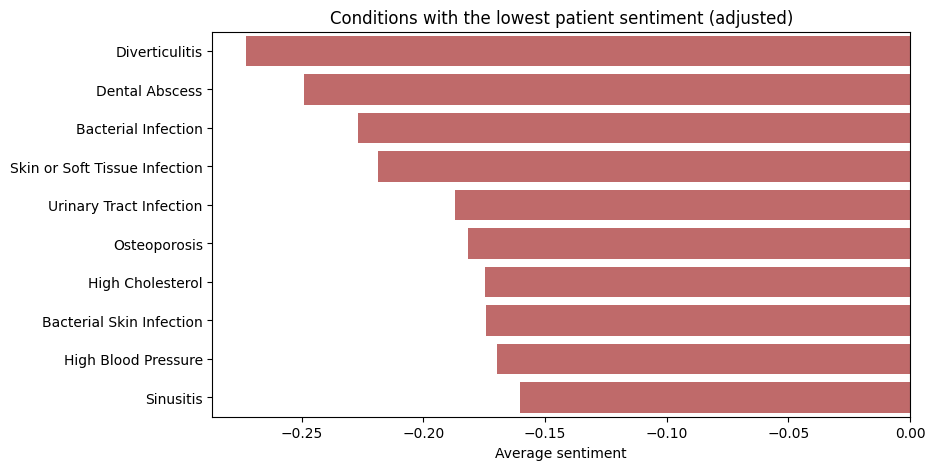

In [17]:
worst = condition_table.sort_values('sentiment_adjusted').head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=worst, x='sentiment_adjusted', y='condition', color='indianred')
plt.title('Conditions with the lowest patient sentiment (adjusted)')
plt.xlabel('Average sentiment')
plt.ylabel('')
plt.show()

## 11. Side effects make people stop taking the drug
When a patient stops a drug or switches to another one, someone pays for it, usually in wasted prescriptions and extra doctor visits. So I looked for reviews where people say they stopped or switched, and checked whether side effects show up more in those reviews.

In [18]:
stop_words = ['stopped taking', 'stop taking', 'quit taking', 'had to stop',
              'discontinued', 'switched to', 'switched from', 'came off', 'coming off']

df['stopped'] = df['clean_review'].str.lower().str.contains('|'.join(stop_words)).astype(int)
unique = df[df['is_duplicate'] == False]

stop_rate = unique['stopped'].mean() * 100
stop_with_effect = unique[unique['any_side_effect'] == 1]['stopped'].mean() * 100
stop_without_effect = unique[unique['any_side_effect'] == 0]['stopped'].mean() * 100

print('Reviews that talk about stopping or switching:', round(stop_rate, 1), '%')
print('...when a side effect is mentioned           :', round(stop_with_effect, 1), '%')
print('...when no side effect is mentioned          :', round(stop_without_effect, 1), '%')

Reviews that talk about stopping or switching: 6.1 %
...when a side effect is mentioned           : 7.8 %
...when no side effect is mentioned          : 4.6 %


In [19]:
# stop rate lift per side effect
stop_results = []

for effect in effect_names:
    reviews = unique[unique[effect].notna()]
    mentioned = reviews[reviews[effect] == 1]
    not_mentioned = reviews[reviews[effect] == 0]

    if len(mentioned) < 50:
        continue

    stop_with = mentioned['stopped'].mean() * 100
    stop_without = not_mentioned['stopped'].mean() * 100

    stop_results.append({
        'Side effect': effect,
        'Stopped % (mentioned)': round(stop_with, 1),
        'Stopped % (not mentioned)': round(stop_without, 1),
        'Times more likely': round(stop_with / stop_without, 2),
    })

stop_table = pd.DataFrame(stop_results).sort_values('Times more likely', ascending=False)
stop_table

,Side effect,Stopped % (mentioned),Stopped % (not mentioned),Times more likely
10,Hair loss,10.6,6.1,1.74
7,Mood swings,9.3,5.6,1.66
14,Heart racing,9.8,6.1,1.61
6,Anxiety,9.3,5.8,1.60
2,Weight gain,9.5,6.0,1.60
9,Skin problems,9.0,5.8,1.54
11,Low sex drive,9.2,6.0,1.52
1,Headache,8.8,5.9,1.49
5,Dizziness,8.7,6.0,1.46
4,Insomnia,8.7,6.1,1.42


## 12. Key numbers

In [20]:
print('Reviews analysed           :', len(df))
print('Unique reviews             :', len(unique))
print('Spearman (normal VADER)    :', round(corr_normal, 2))
print('Spearman (adjusted VADER)  :', round(corr_adjusted, 2))
print('Agreement rate             :', round(agreement, 1), '%')
print('Reviews with a side effect :', round(unique['any_side_effect'].mean() * 100, 1), '%')
print()
print('Top 5 side effects mentioned:')
print(mention_rate.head(5))
print()
print('Top 3 side effects linked to bad ratings:')
print(bad_rating_table[['Side effect', 'Relative risk']].head(3).to_string(index=False))
print()
print('Hidden side effects found  :', len(hidden_table))
if len(hidden_table) > 0:
    print(hidden_table[['Drug', 'Condition', 'Side effect', 'Drug %', 'Condition avg %']].head(3).to_string(index=False))
print()
print('Stop/switch rate with a side effect   :', round(stop_with_effect, 1), '%')
print('Stop/switch rate without a side effect:', round(stop_without_effect, 1), '%')
print('Top 3 side effects linked to stopping:')
print(stop_table[['Side effect', 'Times more likely']].head(3).to_string(index=False))

Reviews analysed           : 212698
Unique reviews             : 127937
Spearman (normal VADER)    : 0.33
Spearman (adjusted VADER)  : 0.35
Agreement rate             : 68.4 %
Reviews with a side effect : 46.8 %

Top 5 side effects mentioned:
Nausea           9.5
Tiredness        9.0
Skin problems    8.1
Headache         8.0
Anxiety          7.8
dtype: float64

Top 3 side effects linked to bad ratings:
  Side effect  Relative risk
 Heart racing           1.81
Skin problems           1.62
  Mood swings           1.59

Hidden side effects found  : 35
          Drug Condition Side effect  Drug %  Condition avg %
Spironolactone      Acne   Dizziness     8.8              1.2
Spironolactone      Acne Weight gain     8.8              1.6
    Quetiapine  Insomnia Weight gain     9.9              2.3

Stop/switch rate with a side effect   : 7.8 %
Stop/switch rate without a side effect: 4.6 %
Top 3 side effects linked to stopping:
 Side effect  Times more likely
   Hair loss               1.74
 

## 13. Limitations
A few things to keep in mind before reading too much into this:
- People who post reviews usually had a strong experience, good or bad. So these numbers describe reviewers, not every patient.
- Word matching is simple. It misses side effects described in other words, and it can't always tell context. A proper medical NLP model would catch more.
- A side effect mentioned in a review is what the patient reported. A doctor never confirmed it, and it doesn't prove the drug caused it.
- "Stopped taking" in a review is only a hint that someone stopped. Real pharmacy data would show it properly.